# Example: Computing Stylized Facts for Daily Equity Growth Rates
A __stylized fact__ is an empirical pattern that appears repeatedly across assets and time periods, although it need not hold exactly for every asset or every sample. Daily equity growth rates commonly exhibit three such patterns: their distributions place more probability in the tails than a Normal model, their signed values have little linear dependence beyond short lags, and the sizes of their movements cluster through time.

In this example, we construct a daily growth-rate series from closing prices and then examine each pattern for one equity. All notation and diagnostics are introduced as they are needed; the notebook does not require the accompanying lecture notes.

> __Learning Objectives:__
>
> By the end of this example, you should be able to:
> * __Task 1:__ Compute and visualize a matrix of daily continuously compounded growth rates.
> * __Task 2:__ Compare the empirical growth-rate distribution with Normal, Laplace, and Student-t models, and estimate its tail index.
> * __Task 3:__ Use autocorrelation to distinguish dependence in the signed growth rate from dependence in the size of its movements.

Let's get started!
___

## Setup, Data, and Prerequisites
First, we set up the computational environment by including the `Include.jl` file and loading any needed resources.

> __Include:__ The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The `Include.jl` file sets paths, loads required external packages, etc. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/). 

Let's set up our code environment:

In [1]:
include(joinpath(@__DIR__, "Include.jl")); # include the Include.jl file

  Activating 

project at `~/Desktop/julia_work/CHEME-5660-CourseRepository-Fall-2026`


For additional information, see the [Julia documentation](https://docs.julialang.org/en/v1/) and the [VLQuantitativeFinancePackage.jl documentation](https://github.com/varnerlab/VLQuantitativeFinancePackage.jl).


### Data

The frozen course dataset contains one table for each security. A security is identified by its __ticker symbol__, such as `AMD`. Each table contains a chronologically ordered sequence of daily open, high, low, and closing prices. The analysis below uses the closing price from each trading day.

The complete collection is stored as a Julia dictionary: each key is a ticker symbol, and the corresponding value is a `DataFrame` containing that security's price history.


In [2]:
original_dataset = MyTrainingMarketDataSet() |> data -> data["dataset"];

Not every ticker has the same number of records. Listings, acquisitions, delistings, and missing observations can shorten a price history. Because [the `log_growth_matrix(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/equity/#VLQuantitativeFinancePackage.log_growth_matrix) constructs a rectangular matrix, we retain the tickers with the maximum available history. This produces a balanced sample in which every retained security contributes the same number of observations. It also excludes shorter histories, so conclusions from this notebook apply to the retained sample rather than automatically to every security in the original dataset.

First, compute that maximum history length.


In [3]:
maximum_number_trading_days = maximum(nrow(frame) for frame in values(original_dataset))

2767

Now collect the ticker histories having exactly `maximum_number_trading_days` observations. We store the result in `dataset::Dict{String,DataFrame}`.


In [4]:
dataset = let
    cleaned = Dict{String,DataFrame}();
    for (ticker, frame) in original_dataset
        if nrow(frame) == maximum_number_trading_days
            cleaned[ticker] = frame;
        end
    end
    cleaned
end;

How much of the original universe remains after the complete-history filter?


In [5]:
data_summary = DataFrame(
    available_tickers=length(original_dataset),
    complete_history_tickers=length(dataset),
    trading_days=maximum_number_trading_days,
);
pretty_table(data_summary; table_format=TextTableFormat(borders=text_table_borders__simple))

==================== ========================== ===============
  available_tickers   complete_history_tickers   trading_days 
              Int64                      Int64          Int64 
==================== ========================== ===============
                515                        424           2767
==================== ========================== ===============


Finally, collect and alphabetize the retained ticker symbols. The position of a ticker in `list_of_tickers` will identify its column in the growth-rate matrix.


In [6]:
list_of_tickers = keys(dataset) |> collect |> sort;

___


## Task 1: Compute the Growth-Rate Matrix

Suppose the cleaned dataset contains $N$ securities observed on $T$ consecutive trading days. We use the following notation:

* $i\in\{1,\ldots,N\}$ identifies a security.
* $j\in\{1,\ldots,T\}$ identifies a trading day.
* $S_j^{(i)}>0$ is the closing share price of security $i$ on trading day $j$, measured in USD/share.
* $t_j$ is the time of observation $j$, measured in years.
* $\Delta t_j=t_j-t_{j-1}$ is the elapsed time between observations $j-1$ and $j$. For equally spaced daily data, we use $\Delta t_j=1/252$ year because a trading year contains approximately 252 trading days.
* $g_{j,j-1}^{(i)}$ is the continuously compounded growth rate of security $i$ over the interval from $t_{j-1}$ to $t_j$, measured in inverse years.

The continuously compounded growth rate is defined by the price-evolution equation

$$
S_j^{(i)}=S_{j-1}^{(i)}\exp\!\left(g_{j,j-1}^{(i)}\Delta t_j\right).
$$

Dividing by $S_{j-1}^{(i)}$, taking the natural logarithm, and solving for $g_{j,j-1}^{(i)}$ gives

$$
g_{j,j-1}^{(i)}=\frac{1}{\Delta t_j}\log\!\left(\frac{S_j^{(i)}}{S_{j-1}^{(i)}}\right).
$$

A positive value of $g_{j,j-1}^{(i)}$ means the closing price increased over the interval; a negative value means it decreased. The associated __log return__ is

$$
r_{j,j-1}^{(i)}=\log\!\left(\frac{S_j^{(i)}}{S_{j-1}^{(i)}}\right)=(\Delta t_j)g_{j,j-1}^{(i)}.
$$

The log return $r_{j,j-1}^{(i)}$ is dimensionless, whereas the growth rate $g_{j,j-1}^{(i)}$ has units of inverse years. From $T$ prices we obtain $T-1$ growth rates. The function `log_growth_matrix(...)` collects them in a matrix $G\in\mathbb{R}^{(T-1)\times N}$: row $j-1$ corresponds to the interval from day $j-1$ to day $j$, and column $i$ corresponds to security $i$. The optional `risk_free_rate` argument can subtract the annualized growth rate of a reference investment treated as risk-free. We set `risk_free_rate=0.0`, so $G$ contains the securities' ordinary growth rates rather than excess growth rates relative to that benchmark.


In [7]:
Δt = 1 / 252;  # one trading day in years
growth_rate_array = log_growth_matrix(
    dataset,
    list_of_tickers;
    Δt=Δt,
    risk_free_rate=0.0,
    keycol=:close,  # use daily closing prices
);

### Select a Ticker

The array `list_of_tickers` determines the column order of $G$. We select the column associated with the ticker stored in `ticker_to_visualize` and call the resulting $(T-1)$-element vector `growth_rate`. Every subsequent diagnostic uses this same growth-rate series. The default choice below is `AMD`; to rerun the analysis for a different security, set `ticker_to_visualize` to any symbol in `list_of_tickers` and re-execute the notebook from this cell.

In [8]:
ticker_to_visualize = "AMD";
ticker_index = only(findall(==(ticker_to_visualize), list_of_tickers));
growth_rate = growth_rate_array[:, ticker_index];

### Visualize the Growth-Rate Path

A time-series plot preserves the order in which the growth rates occurred. The horizontal axis is the trading-day interval index, and the vertical axis is the annualized growth rate $g_{j,j-1}^{(i)}$. Before computing a statistic, look for the location of the series, the frequency of extreme movements, and whether large movements appear independently or in episodes.

What do we observe?


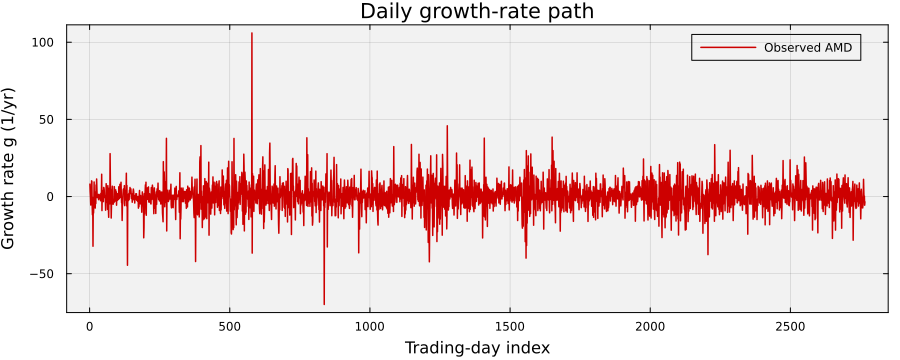

In [9]:
plot(
    growth_rate;
    label="Observed $(ticker_to_visualize)",
    color=:red3,
    linewidth=1.5,
    xlabel="Trading-day index",
    ylabel="Growth rate g (1/yr)",
    title="Daily growth-rate path",
    background_color=:gray95,
    background_color_outside=:white,
    framestyle=:box,
    legend_background_color=nothing,
    left_margin=3Plots.mm,
    bottom_margin=4Plots.mm,
    size=(900, 360),
)

The series fluctuates around a value close to zero, but its variation is not uniform through time. Quiet intervals are interrupted by isolated extremes and by episodes containing many large movements. The path therefore raises two different questions:

1. Does one fixed probability distribution describe the size of the daily movements?
2. Are the movements independent through time?

We address the distributional question first. To simplify notation for the selected security, write $g_t$ for its growth rate during interval $t$. The corresponding log return is $r_t=(\Delta t)g_t$. Because $\Delta t$ is the same positive constant for every observation, $g_t$ and $r_t$ have the same distributional shape, autocorrelation, and tail index; only their numerical scales and units differ. To keep the notebook internally consistent, every diagnostic below is computed from the annualized growth-rate series $\{g_t\}_{t=1}^{T-1}$.


In [10]:
series_summary = DataFrame(
    ticker=ticker_to_visualize,
    observations=length(growth_rate),
    mean_growth_rate_per_year=mean(growth_rate),
    growth_rate_std_per_year=std(growth_rate),
);
pretty_table(series_summary; table_format=TextTableFormat(borders=text_table_borders__simple))

========= ============== =========================== ===========================
  ticker   observations   mean_growth_rate_per_year   growth_rate_std_per_year 
  String          Int64                     Float64                    Float64 
========= ============== =========================== ===========================
     AMD           2766                    0.310468                    8.96318
========= ============== =========================== ===========================


___


## Task 2: Are Daily Growth Rates Normally Distributed?

Let $g_1,\ldots,g_n$ denote the $n=T-1$ observed annualized growth rates in `growth_rate`. A common benchmark treats these observations as __independent and identically distributed__ (i.i.d.) draws from a Normal distribution. “Identically distributed” means that one fixed distribution describes every trading-day interval; “independent” means that knowing past growth rates provides no information about a future growth rate. This task examines the distributional assumption. Task 3 examines temporal dependence.

The empirical growth-rate density is typically more sharply concentrated near zero and places more probability far from zero than a fitted Normal density. This excess tail probability is commonly called a __fat-tail__ or __heavy-tail relative to the Normal__ effect.

We compare three symmetric models:

| Model | Parameters and shape |
|:--|:--|
| Normal | Location $\mu$ and scale $\sigma>0$; smooth center with tails proportional to $\exp(-x^2)$ |
| Laplace | Location $m$ and scale $b>0$; sharper center with tails proportional to $\exp(-|x|)$ |
| Student-t | Location, scale, and degrees of freedom $\nu$; smaller $\nu$ produces slower, power-law tail decay |

__Maximum-likelihood estimation__ chooses model parameters that maximize the probability density assigned to the observed sample. We fit the Normal and Laplace parameters by maximum likelihood. For the Student-t model, we compare a small grid of $\nu$ values; at each candidate $\nu$, the location equals the sample mean and the scale is chosen to match the sample variance. The candidate with the largest sample log likelihood is retained.


In [11]:
normal_fit = fit_mle(Normal, growth_rate);
laplace_fit = fit_mle(Laplace, growth_rate);

ν_grid = [2.5, 3.0, 4.0, 5.0, 6.0, 8.0, 10.0, 15.0, 30.0];
student_candidates = [
    LocationScale(
        mean(growth_rate),
        std(growth_rate) * sqrt((ν_candidate - 2) / ν_candidate),
        TDist(ν_candidate),
    ) for ν_candidate in ν_grid
];
student_log_likelihoods = [
    sum(logpdf.(distribution, growth_rate)) for distribution in student_candidates
];
best_student_index = argmax(student_log_likelihoods);
student_dof = ν_grid[best_student_index];
student_fit = student_candidates[best_student_index];

### Compare the Empirical and Fitted Densities

A probability density describes how probability is distributed across possible growth-rate values. The red “Observed” curve is a kernel-density estimate: a smooth, nonparametric estimate constructed directly from $g_1,\ldots,g_n$. The other curves are the fitted parametric densities.

The left panel uses an ordinary linear vertical scale and therefore emphasizes the high-density center. The right panel shows the same densities on a base-10 logarithmic vertical scale, which separates curves in low-density tail regions. A model can describe the center reasonably well while substantially understating the probability of extreme growth rates.


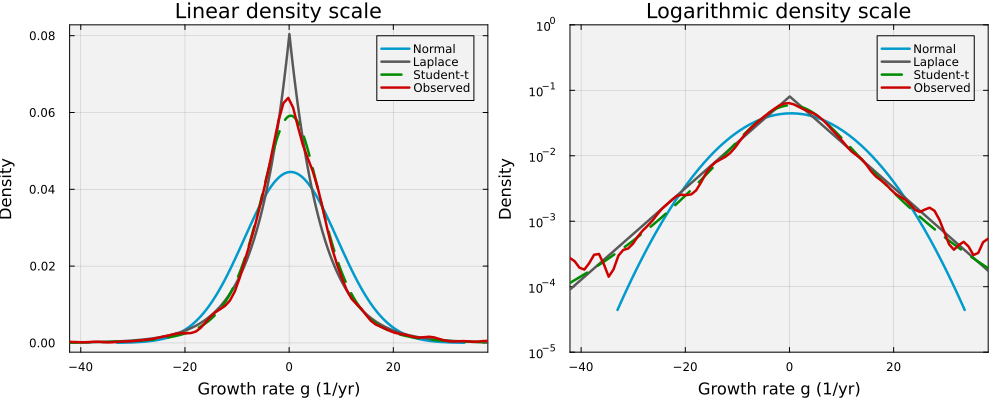

In [12]:
growth_rate_limits = quantile(growth_rate, [0.001, 0.999]);

p_linear = plot(
    normal_fit;
    label="Normal", color=:deepskyblue3, linewidth=2.5,
    xlims=(growth_rate_limits[1], growth_rate_limits[2]),
    xlabel="Growth rate g (1/yr)", ylabel="Density",
    title="Linear density scale", framestyle=:box,
    background_color=:gray95, background_color_outside=:white,
    left_margin=3Plots.mm, bottom_margin=4Plots.mm,
);
plot!(p_linear, laplace_fit; label="Laplace", color=:gray35, linewidth=2.5);
plot!(p_linear, student_fit; label="Student-t", color=:green4, linewidth=2.5, linestyle=:dash);
density!(p_linear, growth_rate; label="Observed", color=:red3, linewidth=2.5);

p_log = plot(
    normal_fit;
    label="Normal", color=:deepskyblue3, linewidth=2.5,
    xlims=(growth_rate_limits[1], growth_rate_limits[2]),
    ylims=(1e-5, 1e0), yscale=:log10,
    xlabel="Growth rate g (1/yr)", ylabel="Density",
    title="Logarithmic density scale", framestyle=:box,
    background_color=:gray95, background_color_outside=:white,
    left_margin=3Plots.mm, bottom_margin=4Plots.mm,
);
plot!(p_log, laplace_fit; label="Laplace", color=:gray35, linewidth=2.5);
plot!(p_log, student_fit; label="Student-t", color=:green4, linewidth=2.5, linestyle=:dash);
density!(p_log, growth_rate; label="Observed", color=:red3, linewidth=2.5);

plot(p_linear, p_log; layout=(1, 2), size=(1000, 400))

What do we observe? The fitted Normal density is too broad near the center and decays too quickly in the tails. The Laplace and Student-t models capture different parts of the empirical shape more successfully. Visual agreement is useful, but we should also compare the fitted models numerically.

For a numerical comparison, let $F_n(x)$ be the empirical cumulative distribution function (the fraction of observed growth rates less than or equal to $x$), and let $F(x)$ be a fitted model's cumulative distribution function. The Anderson–Darling statistic measures the discrepancy between $F_n$ and $F$ while assigning additional weight to their tails. A smaller statistic indicates closer agreement between the sample and the fitted distribution.

The table also reports the sample log likelihood, $\sum_{t=1}^{n}\log f(g_t)$, where $f$ is the fitted density; a larger value indicates that the model assigns more density to the observed sample. Because each model is estimated from the same observations used for comparison, we treat both quantities as relative fit diagnostics rather than using an unadjusted Anderson–Darling p-value as a definitive accept-or-reject decision.


In [13]:
fitted_models = [
    ("Normal", normal_fit),
    ("Laplace", laplace_fit),
    ("Student-t (ν=$(student_dof))", student_fit),
];

fit_comparison = DataFrame(
    distribution=first.(fitted_models),
    AD_statistic=[
        OneSampleADTest(growth_rate, distribution).A²
        for (_, distribution) in fitted_models
    ],
    log_likelihood=[
        sum(logpdf.(distribution, growth_rate))
        for (_, distribution) in fitted_models
    ],
);
sort!(fit_comparison, :AD_statistic);
pretty_table(fit_comparison; table_format=TextTableFormat(borders=text_table_borders__simple))

==================== ============== =================
       distribution   AD_statistic   log_likelihood 
             String        Float64          Float64 
==================== ============== =================
  Student-t (ν=4.0)        1.23176         -9727.11
            Laplace        2.29591         -9736.87
             Normal        31.1763         -9990.47
==================== ============== =================


### Estimate the Tail Index

The density comparison shows that the Normal model misses the tails, but it does not summarize how quickly the probability of an extreme observation decreases. Define the nonnegative magnitude series $X_t=|g_t|$. A power-law tail has the approximate form

$$
\mathbb{P}(X>x)\approx Cx^{-\alpha}\qquad\text{for large }x,
$$

where $C>0$ is a constant and $\alpha>0$ is the __tail index__. Smaller $\alpha$ means slower tail decay and therefore a greater relative frequency of extreme observations.

Let $n$ be the number of positive magnitudes and sort them from largest to smallest: $X_{(1)}\geq X_{(2)}\geq\cdots\geq X_{(n)}$. Hill's estimator uses the $k$ largest magnitudes and the next observation, $X_{(k+1)}$, as a threshold:

$$
\widehat{\alpha}_k=\left[\frac{1}{k}\sum_{m=1}^{k}\log\!\left(\frac{X_{(m)}}{X_{(k+1)}}\right)\right]^{-1}.
$$

The integer $k$ is not a model parameter; it is the analyst's choice of how many extreme observations count as the tail. A very small $k$ produces a noisy estimate, while a large $k$ mixes ordinary observations from the body of the distribution into the tail calculation. We therefore examine $\widehat{\alpha}_k$ across a range of $k$ values rather than reporting one arbitrary result.


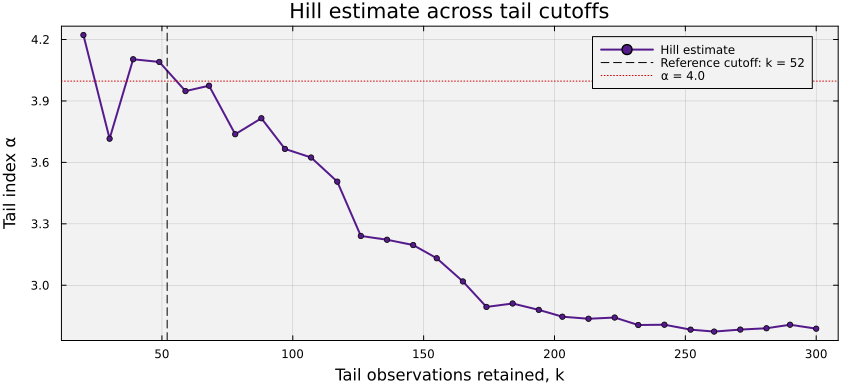

In [14]:
number_of_tail_observations = count(>(0), abs.(growth_rate));
maximum_k = min(300, number_of_tail_observations - 1);
hill_k = unique(round.(Int, range(20, maximum_k; length=30)));
hill_alpha = [
    hill_tail_index(growth_rate; k=k, tail=:absolute) for k in hill_k
];
reference_k = floor(Int, sqrt(number_of_tail_observations));
reference_alpha = hill_tail_index(
    growth_rate; k=reference_k, tail=:absolute
);

plot(
    hill_k, hill_alpha;
    marker=:circle, markersize=3, color=:purple4, linewidth=2,
    label="Hill estimate", xlabel="Tail observations retained, k",
    ylabel="Tail index α", title="Hill estimate across tail cutoffs",
    background_color=:gray95, background_color_outside=:white,
    framestyle=:box, left_margin=3Plots.mm, bottom_margin=4Plots.mm,
    size=(850, 390),
);
vline!([reference_k]; color=:black, linestyle=:dash,
    label="Reference cutoff: k = $(reference_k)");
hline!([reference_alpha]; color=:red3, linestyle=:dot,
    label="α = $(round(reference_alpha, digits=2))")

A plateau over a meaningful range of $k$ would support a stable tail-index estimate. Drift across the plot indicates cutoff sensitivity. The vertical line at $k=\lfloor\sqrt{n}\rfloor$ is a reproducible reference, not a uniquely correct cutoff.


___


## Task 3: Autocorrelation and Volatility Clustering

The density and tail-index calculations treated $g_1,\ldots,g_n$ as an unordered sample. They cannot tell us whether observations separated by one or more trading days are related. We now restore time order and ask two separate questions:

1. Is a signed growth rate $g_t$ linearly related to a later signed growth rate $g_{t+k}$?
2. Is the size of a movement, represented by $|g_t|$, related to the size of a later movement $|g_{t+k}|$?

Here $k$ is a __lag__: $k=1$ compares adjacent trading-day intervals, $k=5$ compares intervals approximately one trading week apart, and so forth. The first question concerns growth-rate autocorrelation. The second concerns volatility clustering.

### Growth-Rate Autocorrelation

For any observed series $x_1,\ldots,x_n$, define its sample mean by $\bar{x}=n^{-1}\sum_{t=1}^{n}x_t$. The sample autocorrelation at lag $k$ is given by:

$$
\widehat{\rho}_x(k)=\frac{\displaystyle\sum_{t=1}^{n-k}(x_t-\bar{x})(x_{t+k}-\bar{x})}{\displaystyle\sum_{t=1}^{n}(x_t-\bar{x})^2}.
$$

The numerator measures whether deviations from the mean tend to have the same sign $k$ observations apart; the denominator normalizes the statistic. The value lies between $-1$ and $1$. Positive values indicate that above-average observations tend to follow above-average observations at that lag, negative values indicate reversal, and values near zero indicate little linear association. Autocorrelation measures linear dependence only; zero autocorrelation does not imply statistical independence.

A random-walk model for prices has uncorrelated price increments and therefore suggests that growth-rate autocorrelation should be close to zero for $k>0$. Under an i.i.d. finite-variance benchmark, an approximate pointwise 95% reference interval for a zero autocorrelation is $\pm 1.96/\sqrt{n}$. “Pointwise” means that the interval applies to one selected lag; it is not a simultaneous 95% statement about all plotted lags, so an uncorrelated series is still expected to cross the band at roughly 5% of the plotted lags by chance. We compute the autocorrelation at every lag out to $k=252$, one trading year, and draw each value as a vertical bar from zero.

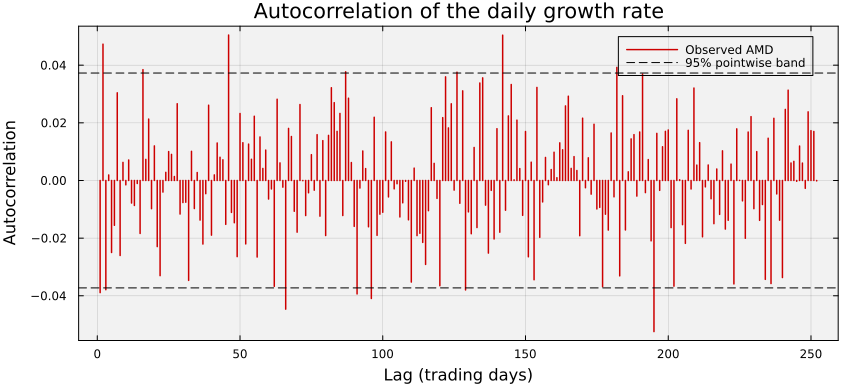

In [15]:
growth_lags = collect(1:252);  # lags out to one trading year
growth_acf = sample_autocorrelation(growth_rate, growth_lags);
pointwise_band = 1.96 / sqrt(length(growth_rate));

plot(
    growth_lags, growth_acf;
    seriestype=:sticks, color=:red3, linewidth=1.5,
    label="Observed $(ticker_to_visualize)",
    xlabel="Lag (trading days)", ylabel="Autocorrelation",
    title="Autocorrelation of the daily growth rate",
    background_color=:gray95, background_color_outside=:white,
    framestyle=:box, legend_background_color=nothing,
    left_margin=3Plots.mm, bottom_margin=4Plots.mm,
    size=(850, 390),
);
hline!([pointwise_band, -pointwise_band];
    color=:black, linestyle=:dash, label="95% pointwise band")

For this AMD sample, the autocorrelations scatter tightly around zero across the full trading year of lags. The bars at lags 1 and 2 that open the plot barely clear the pointwise band, a handful of later bars do the same at scattered lags, and the total number of band crossings over all 252 lags is close to the 5% false-alarm rate that an uncorrelated series would produce. Linear dependence in the signed growth rate is therefore weak at every horizon shown. This still does not establish independence.

To see another form of dependence, return to the growth-rate path. Large positive and negative movements appear in the same episodes. The transformation $v_t=|g_t|$ discards the direction of a movement and keeps its size. We use $v_t$ as an observable proxy for the otherwise unobserved local volatility.

### Volatility Clustering

__Volatility__ describes the scale of growth-rate variation. It is not directly observed from a single daily growth rate, so the magnitude $|g_t|$ (or, in other applications, the square $g_t^2$) is commonly used as a proxy. We work with $|g_t|$: squaring the series lets the few most extreme days dominate the autocorrelation sums, so the absolute-value series yields a stronger and less noisy clustering signal, a pattern known as the Taylor effect. __Volatility clustering__ means that high-magnitude periods tend to follow high-magnitude periods and low-magnitude periods tend to follow low-magnitude periods, regardless of whether prices move up or down.

We diagnose clustering by applying the same autocorrelation formula to $v_t=|g_t|$ over the same one-year range of lags. Positive values of $\widehat{\rho}_{|g|}(k)$ indicate that movement sizes $k$ trading days apart tend to be similar.

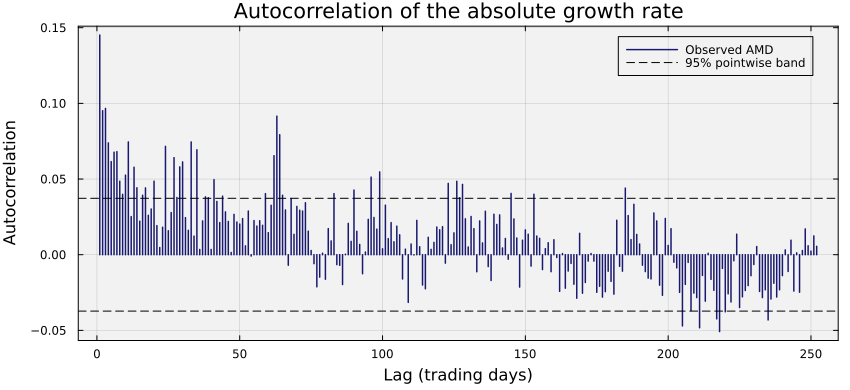

In [16]:
volatility_lags = collect(1:252);
absolute_growth_acf = sample_autocorrelation(abs.(growth_rate), volatility_lags);

plot(
    volatility_lags, absolute_growth_acf;
    seriestype=:sticks, color=:midnightblue, linewidth=1.5,
    label="Observed $(ticker_to_visualize)",
    xlabel="Lag (trading days)", ylabel="Autocorrelation",
    title="Autocorrelation of the absolute growth rate",
    background_color=:gray95, background_color_outside=:white,
    framestyle=:box, legend_background_color=nothing,
    left_margin=3Plots.mm, bottom_margin=4Plots.mm,
    size=(850, 390),
);
hline!([pointwise_band, -pointwise_band];
    color=:black, linestyle=:dash, label="95% pointwise band")

The contrast with the signed-growth autocorrelation is immediate. The autocorrelation of $|g_t|$ starts near $0.15$, remains positive at nearly every lag over the first three months, and decays toward the pointwise band only gradually, with bars still crossing it more than 150 trading days out. Dependence in movement size persists long after the signed autocorrelations have settled into chance-level behavior. This is the volatility-clustering result: the direction of a daily move loses linear memory within days, while its size holds memory for months.

___

## Summary

This example constructed an annualized daily growth-rate series from closing prices and used it to examine three stylized facts for AMD.

> __Key Takeaways:__
>
> * __Growth rates connect consecutive prices:__ The continuously compounded growth rate is the natural logarithm of the consecutive-price ratio divided by the time-step length, giving it units of inverse years.
> * __The Normal distribution understates extreme growth rates:__ The empirical density and relative-fit statistics show that the observed growth-rate distribution is more sharply peaked and has more tail probability than a fitted Normal model, while the Hill analysis shows how sensitive tail-index estimates are to the chosen cutoff.
> * __Weak signed dependence can coexist with volatility clustering:__ Most plotted nonzero-lag autocorrelations of the signed growth rate are small, while the slowly decaying positive autocorrelation of the magnitude series indicates temporal dependence in the sizes of movements.

Together, these results show why a useful growth-rate model must be evaluated against distributional shape, extreme-event behavior, and temporal dependence rather than against a single summary statistic.

___

## Disclaimer and Risks

__This content is offered solely for training and informational purposes__. No offer or solicitation to buy or sell securities or derivative products, and no investment or trading advice or strategy, is made, given, or endorsed by the teaching team.

__Trading involves risk__. Carefully review your financial situation before investing. Past performance, whether actual or indicated by historical tests, is no guarantee of future performance or success.

__You are fully responsible for any investment or trading decisions you make__. Distributional fits are approximations, Hill estimates are cutoff-sensitive, and the ACF reference bands shown above are pointwise large-sample diagnostics.

___
